# 0. Intro

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: '{:.0f}'.format(x) if int(x) == x else '{:.3f}'.format(x))

In [4]:
# Get Ames housing data
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = ames.frame.copy()
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')

In [5]:
# Let's look at some data
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',None,0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.shape


(1460, 81)

In [7]:
df.info()
# - Some columns have a lot of null data
# - Mix of numerical and object data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
A =  df.isnull().sum().pipe(lambda x: x[x > 0]).sort_values(ascending=False)
print(f"Columns with missing data: {len(A)}")
A
# => Most homes do not have these features:
#   - pool (confirm pool area is zero)
#   - misc feature
#   - alley
#   - fence

Columns with missing data: 19


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
FireplaceQu,690
LotFrontage,259
GarageCond,81
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [9]:
df.describe().sort_index(axis=1).T
# n.b. We sort in order of column name (axis=1)
# Only numeric columns are considered here.

,count,mean,std,min,25%,50%,75%,max
1stFlrSF,1460,1162.627,386.588,334,882,1087,1391.250,4692
2ndFlrSF,1460,346.992,436.528,0,0,0,728,2065
3SsnPorch,1460,3.410,29.317,0,0,0,0,508
BedroomAbvGr,1460,2.866,0.816,0,2,3,3,8
BsmtFinSF1,1460,443.640,456.098,0,0,383.500,712.250,5644
BsmtFinSF2,1460,46.549,161.319,0,0,0,0,1474
BsmtFullBath,1460,0.425,0.519,0,0,0,1,3
BsmtHalfBath,1460,0.058,0.239,0,0,0,0,2
BsmtUnfSF,1460,567.240,441.867,0,223,477.500,808,2336
EnclosedPorch,1460,21.954,61.119,0,0,0,0,552


There are three float fields:
* `GarageYrBuilt`: year garage was built
* `MasVnrArea`: masonry veneer area
* `LotFrontage`: linear feet of street connected to property

However, these seem to all have integer values.

In [10]:
# No duplicate rows
df.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'Sale Price (log normal)')

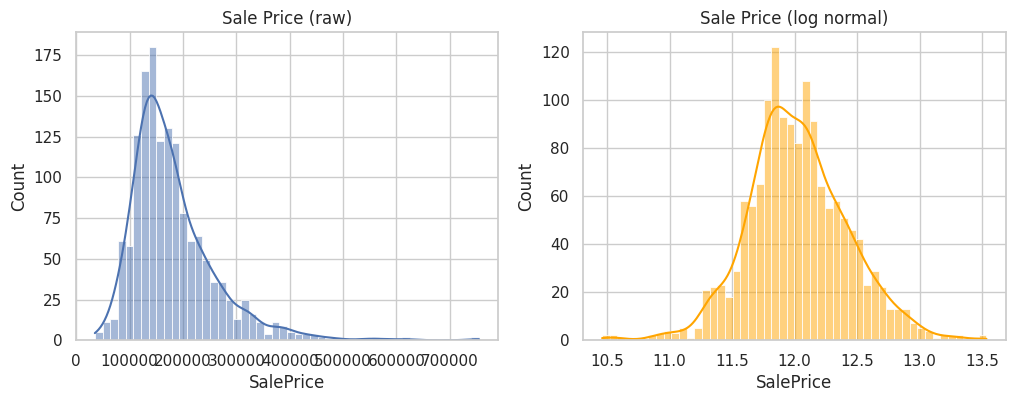

In [11]:
# Let's consider the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['SalePrice'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Sale Price (raw)")
# => Outliers at 700k, mean = ~150k (as per describe above, mean = 180k, std = 80k)
# (right-skewed)

sns.histplot(np.log1p(df['SalePrice']), bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title("Sale Price (log normal)")
# (normalised)

# 1. Split dataset

In [12]:
# Extract input features, target column
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Split the data set into 3 groups: train, validate, test (60/20/20 split)
# 1. Split into two groups to extract test set (60 %)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42)

# 2. Split temp set (40 %) into two equal halves (20/20)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

total = len(df)
print(f"Train:      {len(X_train):4} rows ({len(X_train)/total*100} %)")
print(f"Validation: {len(X_val):4} rows ({len(X_val)/total*100} %)")
print(f"Test:       {len(X_test):4} rows ({len(X_test)/total*100} %)")
print(f"Total:      {total:4} rows")

Train:       876 rows (60.0 %)
Validation:  292 rows (20.0 %)
Test:        292 rows (20.0 %)
Total:      1460 rows


In [13]:
# Compare SalePrice statistics across splits
split_comparison = pd.DataFrame({
    'Train':      y_train.describe(),
    'Validation': y_val.describe(),
    'Test':       y_test.describe()
}).round(0)

print('SalePrice distribution per split:')
split_comparison
# => Validation set is slightly higher in mean, std as it contains larger outliers
# But the overall data distribution is similar across the three sets.

SalePrice distribution per split:


,Train,Validation,Test
count,876,292,292
mean,179922,192100,172740
std,75389,97209,70053
min,34900,35311,52000
25%,129000,134900,128838
50%,164945,170000,153950
75%,213625,221908,206600
max,625000,755000,485000


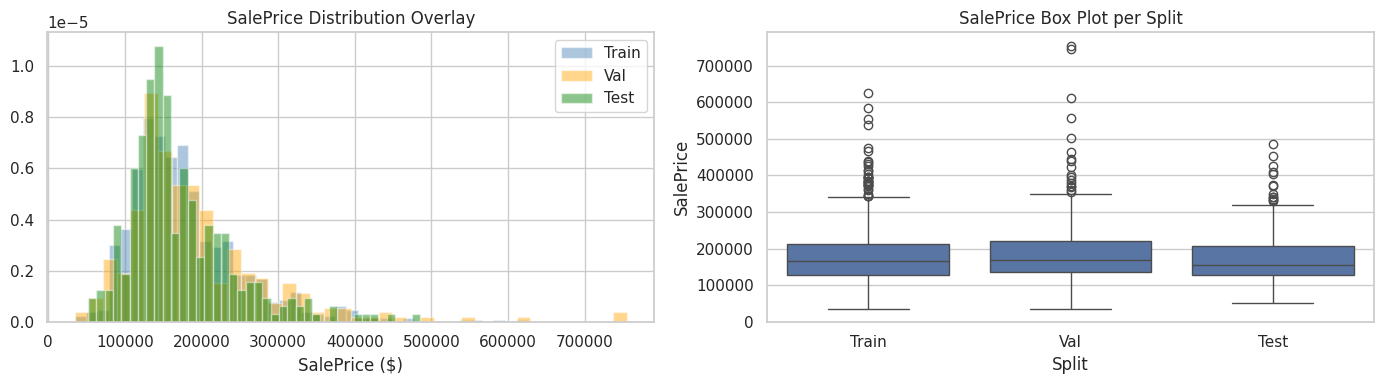

The three splits look similar — the random split is balanced.


In [14]:
# Overlay SalePrice distributions across splits
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram overlay
for name, series, color in [('Train', y_train, 'steelblue'),
                              ('Val',   y_val,   'orange'),
                              ('Test',  y_test,  'green')]:
    axes[0].hist(series, bins=40, alpha=0.45, label=name, color=color, density=True)
axes[0].set_title('SalePrice Distribution Overlay')
axes[0].set_xlabel('SalePrice ($)')
axes[0].legend()

# Box plot
split_df = pd.DataFrame({
    'SalePrice': pd.concat([y_train, y_val, y_test]),
    'Split': (['Train'] * len(y_train) + ['Val'] * len(y_val) + ['Test'] * len(y_test))
})
sns.boxplot(data=split_df, x='Split', y='SalePrice', ax=axes[1],
            order=['Train', 'Val', 'Test'])
axes[1].set_title('SalePrice Box Plot per Split')

plt.tight_layout()
plt.show()

print('The three splits look similar — the random split is balanced.')

# 2. Handle missing values

In [15]:
# Null summary on training set only
null_counts = X_train.isnull().sum()
null_pct    = (null_counts / len(X_train) * 100).round(1)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_pct':   null_pct,
    'dtype':      X_train.dtypes
}).query('null_count > 0').sort_values('null_pct', ascending=False)

print(f'Columns with missing values: {len(null_summary)}')
null_summary

Columns with missing values: 19


,null_count,null_pct,dtype
PoolQC,872,99.500,object
MiscFeature,839,95.800,object
Alley,818,93.400,object
Fence,709,80.900,object
FireplaceQu,420,47.900,object
LotFrontage,167,19.100,float64
GarageCond,46,5.300,object
GarageType,46,5.300,object
GarageYrBlt,46,5.300,float64
GarageFinish,46,5.300,object


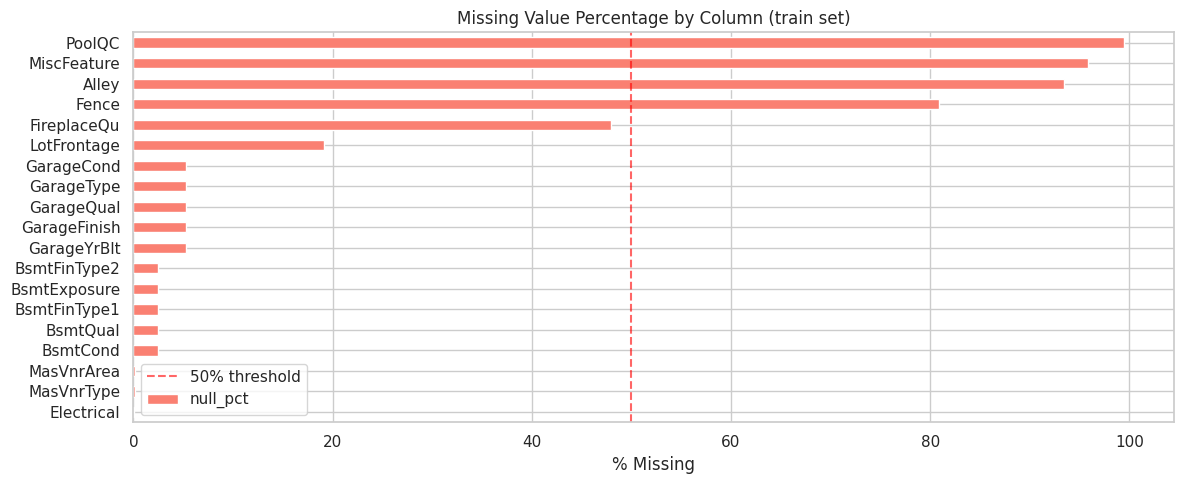

In [16]:
# Bar chart of null percentages
plt.figure(figsize=(12, 5))
null_summary['null_pct'].sort_values(ascending=True).plot(
    kind='barh', color='salmon', edgecolor='white'
)
plt.axvline(50, color='red', linestyle='--', alpha=0.6, label='50% threshold')
plt.title('Missing Value Percentage by Column (train set)')
plt.xlabel('% Missing')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Split null summary by dtype — helps plan strategy
print('Null columns by dtype:')
print(null_summary.groupby('dtype')['null_count'].count())
print()
print('Numeric nulls:')
print(null_summary[null_summary['dtype'] != 'object'][['null_count', 'null_pct']])
print()
print('Categorical nulls:')
print(null_summary[null_summary['dtype'] == 'object'][['null_count', 'null_pct']])

Null columns by dtype:
dtype
float64     3
object     16
Name: null_count, dtype: int64

Numeric nulls:
             null_count  null_pct
LotFrontage         167    19.100
GarageYrBlt          46     5.300
MasVnrArea            2     0.200

Categorical nulls:
              null_count  null_pct
PoolQC               872    99.500
MiscFeature          839    95.800
Alley                818    93.400
Fence                709    80.900
FireplaceQu          420    47.900
GarageCond            46     5.300
GarageType            46     5.300
GarageFinish          46     5.300
GarageQual            46     5.300
BsmtQual              22     2.500
BsmtCond              22     2.500
BsmtFinType1          22     2.500
BsmtExposure          22     2.500
BsmtFinType2          22     2.500
MasVnrType             2     0.200
Electrical             1     0.100


In [18]:
# Also check columns with zero value
(X_train.select_dtypes(include='number') == 0).sum().sort_values(ascending=False).head(20)

,0
PoolArea,872
LowQualFinSF,860
3SsnPorch,860
MiscVal,839
BsmtHalfBath,823
ScreenPorch,798
BsmtFinSF2,783
EnclosedPorch,759
HalfBath,548
BsmtFullBath,517


In [19]:
# Let's look at numerical columns first
X_train[['LotFrontage', 'GarageYrBlt', 'MasVnrArea']].describe().T

# LotFrontage: Mean/median align, use median value (59)
# GarageYrBlt: Represents year, again, just median (1980)
# MasVnrArea: Not sure what this value represents and why it's numerical, we can
# just set to 0 (most common value)

,count,mean,std,min,25%,50%,75%,max
LotFrontage,709,69.748,26.157,21,59,68,80,313
GarageYrBlt,830,1978.400,25.129,1900,1961,1980,2002,2010
MasVnrArea,874,103.936,171.436,0,0,0,169.500,1378


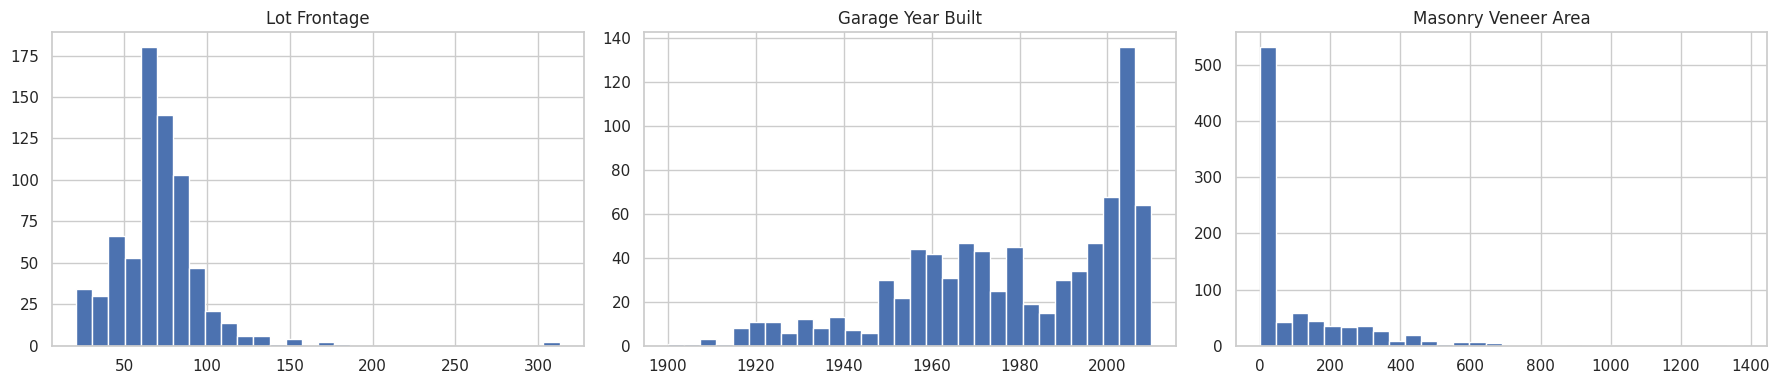

In [20]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: Lot Frontage
X_train['LotFrontage'].hist(bins=30, ax=axes[0])
axes[0].set_title('Lot Frontage')

# Plot 2: GarageYrBlt
X_train['GarageYrBlt'].hist(bins=30, ax=axes[1])
axes[1].set_title('Garage Year Built')

# Plot 3: MasVnrArea
X_train['MasVnrArea'].hist(bins=30, ax=axes[2])
axes[2].set_title('Masonry Veneer Area')

plt.tight_layout()
plt.show()

**DECISION:**
Set:
* LotFrontage -> median
* GarageYrBlt -> median
* MasVnrArea -> mode (0)

<Axes: >

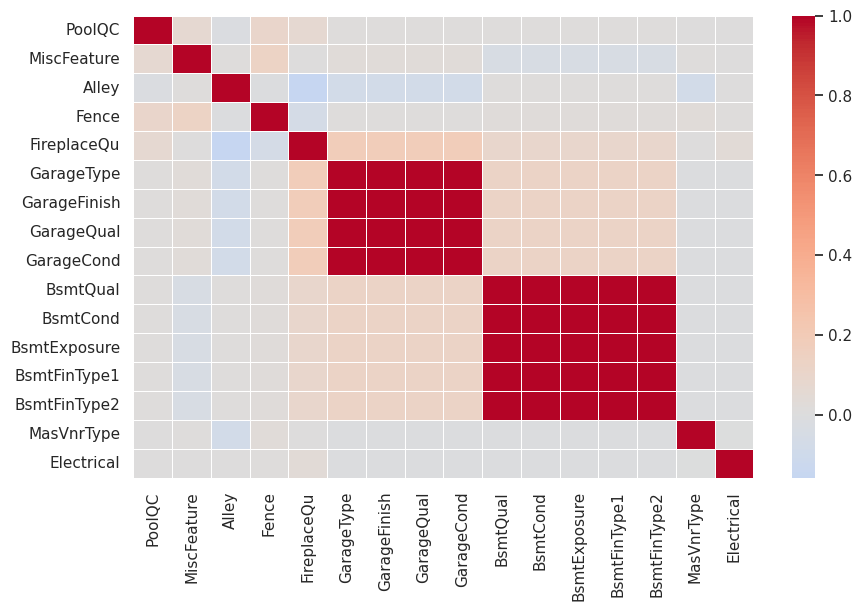

In [21]:
# Heatmap of all null co-occurrences (categorical columns)
null_categ_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType', 'Electrical'
]

null_indicator = X_train[[c for c in null_categ_cols]].isnull().astype(int)
plt.figure(figsize=(10,6))
sns.heatmap(null_indicator.corr(), cmap='coolwarm', center=0, linewidths=0.5)
# n.b. With center=0, negative correlations are blue instead of zero correlation

# We can see Garage features are heavily correlated, so are Basement features.

In [22]:
# Let's see if we can consolidate on the pool parameters: PoolArea, PoolQC
X_train['PoolArea'].value_counts()
# => Only 4 nonzero values

# Compare to sale price
X_train[X_train['PoolArea'] > 0][['PoolArea']].join(y_train)

,PoolArea,SalePrice
1298,480,160000
197,512,235000
1386,519,250000
1423,738,274970


In [23]:
# Pool quality values
X_train['PoolQC'].value_counts()

,count
PoolQC,
Gd,2
Ex,1
Fa,1


Sale price is a little above the mean, so a pool probably adds value, but there is so few example data that we can probably drop this column. For now, we'll zero out PoolQC column but when we train we'll delete it.

**DECISION:** Delete PoolQC (zero it out for now)

In [24]:
garage_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
X_train[garage_cols].head()

,GarageType,GarageFinish,GarageQual,GarageCond
314,Detchd,Unf,Fa,TA
442,Detchd,Unf,TA,TA
319,Attchd,Unf,TA,TA
767,Attchd,Unf,TA,TA
756,Attchd,RFn,TA,TA


In [25]:
X_train[garage_cols].value_counts()

GarageType  GarageFinish  GarageQual  GarageCond
Attchd      RFn           TA          TA            208
Detchd      Unf           TA          TA            183
Attchd      Fin           TA          TA            170
            Unf           TA          TA            123
BuiltIn     Fin           TA          TA             35
            RFn           TA          TA             14
Detchd      Unf           Fa          Fa             12
            Fin           TA          TA             10
            RFn           TA          TA              9
            Unf           Fa          TA              9
                          TA          Fa              8
CarPort     Unf           TA          TA              6
Basment     RFn           TA          TA              5
BuiltIn     Unf           TA          TA              4
Basment     Unf           TA          TA              4
Attchd      RFn           Gd          TA              3
2Types      Unf           TA          TA              2
Attchd      RFn           TA          Gd              2
            Unf           Fa          TA              2
Basment     Unf           Fa          TA              2
Attchd      RFn           Gd          Gd              2
Detchd      Unf           TA          Gd              2
Attchd      Fin           Gd          Gd              1
2Types      RFn           TA          TA              1
            Unf           Fa          Fa              1
BuiltIn     Fin           Gd          TA              1
Basment     Fin           TA          TA              1
Attchd      Unf           Gd          Gd              1
                          TA          Fa              1
Detchd      Unf           Ex          TA              1
                                      Ex              1
            Fin           Ex          Ex              1
                          TA          Fa              1
CarPort     Unf           Fa          Fa              1
Detchd      Unf           Fa          Po              1
                          Gd          TA              1
                          Po          Po              1
Name: count, dtype: int64

In [26]:
for c in garage_cols:
  print(X_train[c].value_counts())
  print(f"null = {(X_train[c].isnull()).sum()}\n")

GarageType
Attchd     513
Detchd     240
BuiltIn     54
Basment     12
CarPort      7
2Types       4
Name: count, dtype: int64
null = 46

GarageFinish
Unf    366
RFn    244
Fin    220
Name: count, dtype: int64
null = 46

GarageQual
TA    789
Fa     28
Gd      9
Ex      3
Po      1
Name: count, dtype: int64
null = 46

GarageCond
TA    794
Fa     24
Gd      8
Po      2
Ex      2
Name: count, dtype: int64
null = 46



The null values correspond to "No garage". Therefore, we encode this value for each column with 'None'.

**DECISION:** Fill missing Garage columns with 'None'.

In [27]:
basement_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for c in basement_cols:
  print(X_train[c].value_counts())
  print(f"null = {(X_train[c].isnull()).sum()}\n")

BsmtQual
TA    384
Gd    373
Ex     71
Fa     26
Name: count, dtype: int64
null = 22

BsmtCond
TA    786
Gd     37
Fa     30
Po      1
Name: count, dtype: int64
null = 22

BsmtExposure
No    580
Av    125
Gd     84
Mn     65
Name: count, dtype: int64
null = 22

BsmtFinType1
Unf    253
GLQ    249
ALQ    135
BLQ     92
Rec     79
LwQ     46
Name: count, dtype: int64
null = 22

BsmtFinType2
Unf    761
Rec     34
LwQ     26
ALQ     13
BLQ     13
GLQ      7
Name: count, dtype: int64
null = 22



The null values correspond to "No basement". Therefore, we encode this value for each column with 'None'.

**DECISION:** Fill missing Basement columns with 'None'.

In [28]:
misc_cols = ['MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType', 'Electrical']
for c in misc_cols:
  print(X_train[c].value_counts())
  print(f"null = {(X_train[c].isnull()).sum()}\n")

MiscFeature
Shed    35
Gar2     1
TenC     1
Name: count, dtype: int64
null = 839

Alley
Grvl    38
Pave    20
Name: count, dtype: int64
null = 818

Fence
MnPrv    89
GdWo     37
GdPrv    33
MnWw      8
Name: count, dtype: int64
null = 709

FireplaceQu
Gd    224
TA    186
Fa     19
Ex     14
Po     13
Name: count, dtype: int64
null = 420

MasVnrType
None       507
BrkFace    279
Stone       76
BrkCmn      12
Name: count, dtype: int64
null = 2

Electrical
SBrkr    801
FuseA     52
FuseF     20
FuseP      2
Name: count, dtype: int64
null = 1



For all features except 'Electrical' and 'MasVnrType', we can set value to 'None', as most properties are missing the feature.

**DECISION:** Set missing values for 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu' to 'None'.

For 'Electrical' and 'MasVnrType', there's very few missing values; we set these to the most common value (801, 'None', respectively).

**DECISION:** Set missing 'Electrical', 'MasVnrType' to mode.

In [29]:
# Final summary
# Fill with zero
zero_cols = ['PoolQC']

# Fill with 'None'
none_cols = [
    'GarageCond', 'GarageType', 'GarageFinish', 'GarageQual',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType', 'BsmtFinType1', 'BsmtFinType2',
    'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
]

# Fill with median
median_cols = ['LotFrontage', 'GarageYrBlt']

# Fill with mode
mode_cols = ['MasVnrArea', 'MasVnrType', 'Electrical']

# Strategy summary table
strategy_rows = []
for col in zero_cols:
    strategy_rows.append({'column': col, 'strategy': 'fill 0', 'reason': 'structural — feature absent'})
for col in none_cols:
    strategy_rows.append({'column': col, 'strategy': "fill 'None'", 'reason': 'structural — area/count is 0'})
for col in median_cols:
    strategy_rows.append({'column': col, 'strategy': 'median (train)', 'reason': 'unknown — measurement gap'})
for col in mode_cols:
    strategy_rows.append({'column': col, 'strategy': 'mode (train)', 'reason': 'unknown — recording gap'})

strategy_df = pd.DataFrame(strategy_rows)
print('Imputation decision log:')
strategy_df

Imputation decision log:


,column,strategy,reason
0,PoolQC,fill 0,structural — feature absent
1,GarageCond,fill 'None',structural — area/count is 0
2,GarageType,fill 'None',structural — area/count is 0
3,GarageFinish,fill 'None',structural — area/count is 0
4,GarageQual,fill 'None',structural — area/count is 0
5,BsmtQual,fill 'None',structural — area/count is 0
6,BsmtCond,fill 'None',structural — area/count is 0
7,BsmtExposure,fill 'None',structural — area/count is 0
8,BsmtFinType,fill 'None',structural — area/count is 0
9,BsmtFinType1,fill 'None',structural — area/count is 0


In [30]:
unhandled_null_cols = 0
for c in null_summary.index:
  if c not in zero_cols + none_cols + median_cols + mode_cols:
    print(f"Missing column: {c}")
    unhandled_null_cols += 1
if unhandled_null_cols == 0:
  print("No unhandled null columns")

No unhandled null columns


In [31]:
# Define imputation function and apply
def apply_imputation(X_tr, X_v, X_te,
                     cat_none_cols, num_zero_cols,
                     num_median_cols, cat_mode_cols):
    X_tr = X_tr.copy()
    X_v  = X_v.copy()
    X_te = X_te.copy()

    # Categorical structural -> 'None'
    for col in cat_none_cols:
        if col in X_tr.columns:
            X_tr[col] = X_tr[col].fillna('None')
            X_v[col]  = X_v[col].fillna('None')
            X_te[col] = X_te[col].fillna('None')

    # Numeric structural -> 0
    for col in num_zero_cols:
        if col in X_tr.columns:
            X_tr[col] = X_tr[col].fillna(0)
            X_v[col]  = X_v[col].fillna(0)
            X_te[col] = X_te[col].fillna(0)

    # Numeric unknown -> median (fit on train only)
    # The `fit_transform` function learns the median only from the training data
    # (X_tr), then applies it to the other datasets (X_v, X_te) via `transform`
    med_imp = SimpleImputer(strategy='median')
    for col in num_median_cols:
        if col in X_tr.columns:
            X_tr[[col]] = med_imp.fit_transform(X_tr[[col]])
            X_v[[col]]  = med_imp.transform(X_v[[col]])
            X_te[[col]] = med_imp.transform(X_te[[col]])

    # Categorical unknown -> mode (fit on train only)
    # See note above for median
    mode_imp = SimpleImputer(strategy='most_frequent')
    for col in cat_mode_cols:
        if col in X_tr.columns:
            X_tr[[col]] = mode_imp.fit_transform(X_tr[[col]])
            X_v[[col]]  = mode_imp.transform(X_v[[col]])
            X_te[[col]] = mode_imp.transform(X_te[[col]])

    return X_tr, X_v, X_te


X_train_imp, X_val_imp, X_test_imp = apply_imputation(
    X_train, X_val, X_test,
    none_cols, zero_cols, median_cols, mode_cols
)
print('Imputation applied')

Imputation applied


/tmp/ipykernel_24983/1664852301.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_te[col] = X_te[col].fillna(0)


In [32]:
# Check 1: null counts
print(f'Remaining nulls in train: {X_train_imp.isnull().sum().sum()}')
print(f'Remaining nulls in val:   {X_val_imp.isnull().sum().sum()}')
print(f'Remaining nulls in test:  {X_test_imp.isnull().sum().sum()}')

Remaining nulls in train: 0
Remaining nulls in val:   0
Remaining nulls in test:  0


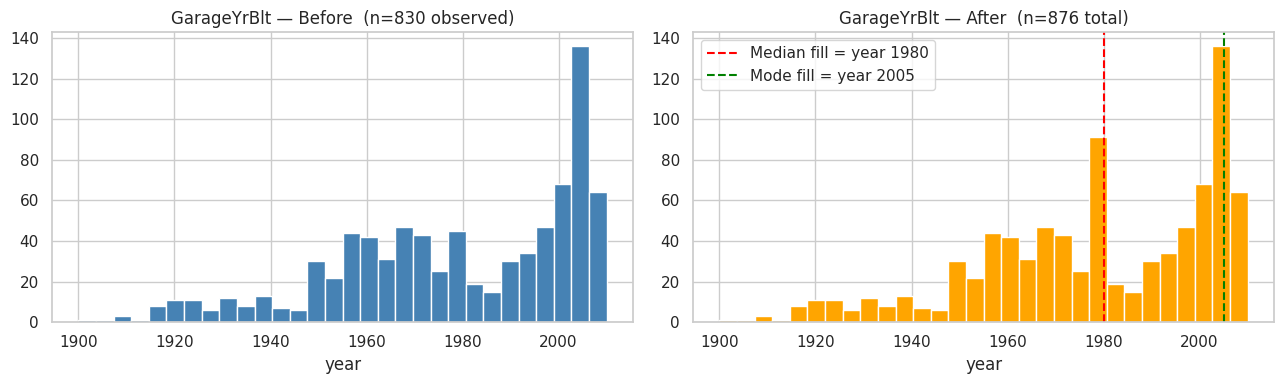

In [33]:
# Check 2a: GarageYrBlt distribution before vs after
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

X_train['GarageYrBlt'].dropna().hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'GarageYrBlt — Before  (n={X_train["GarageYrBlt"].notna().sum()} observed)')
axes[0].set_xlabel('year')

X_train_imp['GarageYrBlt'].hist(bins=30, ax=axes[1], color='orange', edgecolor='white')
train_median = X_train['GarageYrBlt'].median()
train_mode = X_train['GarageYrBlt'].mode()[0]  # mode is returned as a Series (in case there are multiple modes)
axes[1].axvline(train_median, color='red', linestyle='--', label=f'Median fill = year {train_median:.0f}')
axes[1].axvline(train_mode, color='green', linestyle='--', label=f'Mode fill = year {train_mode:.0f}')
axes[1].set_title(f'GarageYrBlt — After  (n={len(X_train_imp)} total)')
axes[1].set_xlabel('year')
axes[1].legend()

plt.tight_layout()
plt.show()

Distribution for GarageYrBlt looks similar after imputation, but there is a spike now the median (1980), much more noticeable than before. Maybe we should have picked the mode value instead (2005).

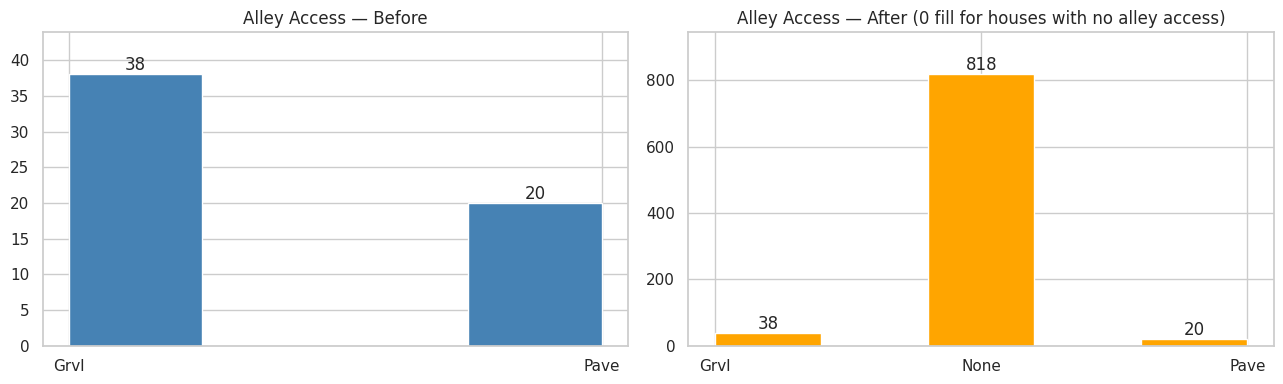

The spike at 0 is correct: Most houses do not have alley access.


In [34]:
# Check 2b: Alley — numeric structural fill (0 = no alley access)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Draw histograms on the respective axes
X_train['Alley'].dropna().hist(bins=4, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Alley Access — Before')

X_train_imp['Alley'].hist(bins=5, ax=axes[1], color='orange', edgecolor='white')
axes[1].set_title('Alley Access — After (0 fill for houses with no alley access)')

# Loop through each axes and its patches to add text
for i, ax_obj in enumerate(axes):
    for patch in ax_obj.patches:
        height = patch.get_height()
        if height > 0:
          ax_obj.text(patch.get_x() + patch.get_width()/2, height,
                int(height), ha='center', va='bottom')

# Add 10 % margin to vertical axis
for ax_obj in axes:
    ax_obj.set_ylim(0, ax_obj.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()
print('The spike at 0 is correct: Most houses do not have alley access.')

In [35]:
# Check 3: PoolQC value counts after fill — 'None' should now be the dominant level
print('PoolQC value counts after imputation (train):')
print(X_train_imp['PoolQC'].value_counts())
print()
print('GarageType value counts after imputation (train):')
print(X_train_imp['GarageType'].value_counts())

PoolQC value counts after imputation (train):
PoolQC
0     872
Gd      2
Ex      1
Fa      1
Name: count, dtype: int64

GarageType value counts after imputation (train):
GarageType
Attchd     513
Detchd     240
BuiltIn     54
None        46
Basment     12
CarPort      7
2Types       4
Name: count, dtype: int64


# 3. Encode and scale

In [36]:
X_train_imp.shape, X_val_imp.shape, X_test_imp.shape

((876, 80), (292, 80), (292, 80))

In [37]:
print(f"We started with {X_train.isnull().sum().sum()} null values, now we have "
      f"{X_train_imp.isnull().sum().sum()} null values in the imputed data.")

We started with 4170 null values, now we have 0 null values in the imputed data.


In [38]:
null_counts = X_train.isnull().sum()
pd.DataFrame({'null_count': null_counts}).query('null_count > 0')

,null_count
LotFrontage,167
Alley,818
MasVnrType,2
MasVnrArea,2
BsmtQual,22
BsmtCond,22
BsmtExposure,22
BsmtFinType1,22
BsmtFinType2,22
Electrical,1


In [39]:
null_counts = X_train.isnull().sum()
null_counts[null_counts > 0]

,0
LotFrontage,167
Alley,818
MasVnrType,2
MasVnrArea,2
BsmtQual,22
BsmtCond,22
BsmtExposure,22
BsmtFinType1,22
BsmtFinType2,22
Electrical,1
